# 🧪 Identifying Food Intolerances Using Cross-Correlation
This notebook documents a personal project undertaken during the COVID-19 lockdown to identify potential food intolerances in a family member using signal processing techniques. The idea was inspired by methods used in magnetic brain signal research, [which I was working on at the time](https://www.nature.com/articles/s41598-021-01854-7), particularly **cross-correlation** to detect time-delayed responses.

## 🧠 Background
As a physicist with experience in magnetic sensing and time-series analysis, I applied my knowledge of **cross-correlation**—often used to measure time delays in neural signals—to gastrointestinal symptoms.

**Problem:** A family member was suffering from symptoms like bloating and facial swelling after meals. Access to allergy testing was delayed.

**Question:** Could I use timestamped food and symptom logs to uncover which foods were likely causing the reactions?

## 📅 Data Collection
- 11 days of food and symptom logging.
- Each entry recorded intake of possible allergens: `sulphites`, `gluten`, `dairy`, `nuts`, `OAS (pollen)`, and `yeast`.
- Binary encoding for presence (1) or absence (0) of each allergen and symptom.
- Time resolution: 30-minute intervals.

In [1]:
import time
import datetime
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
pdData = pd.read_excel('allergy_calendar.xlsx')
data = np.array(pdData)
del pdData

## Data Processing

In [3]:
times = np.empty([len(data)])

for i in range(len(data)):
    tStamp = str(data[i,0]) + '/'+ str(data[i,1]) + '/' + str(data[i,2]) + ':' + str(data[i,3]) + ':' + str(data[i,4])
    times[i] = time.mktime(datetime.datetime.strptime(tStamp, "%Y/%m/%d:%H:%M").timetuple())
    
times = times - times[0]

In [4]:
# now look at data for cross-correlation
analysisTimes = np.arange(0,times[-1]+1800,1800)
analysisData = np.zeros([len(analysisTimes),7])

for i in range(len(data)):
    for j in range(len(analysisTimes)):
        if analysisTimes[j] == times[i]:
            analysisData[j] = data[i,5:]
            
lagXvalues = np.arange(-len(analysisTimes),len(analysisTimes))[1:]/2

legendText = ['Sulphite','Gluten','Dairy','Nuts','OAS','Yeast','Reaction?']

## Initial Visualisation
The plot below shows each allergen (and reactions) across time, padded for 30-minute windows before and after food intake events. This simulates digestion delay effects.

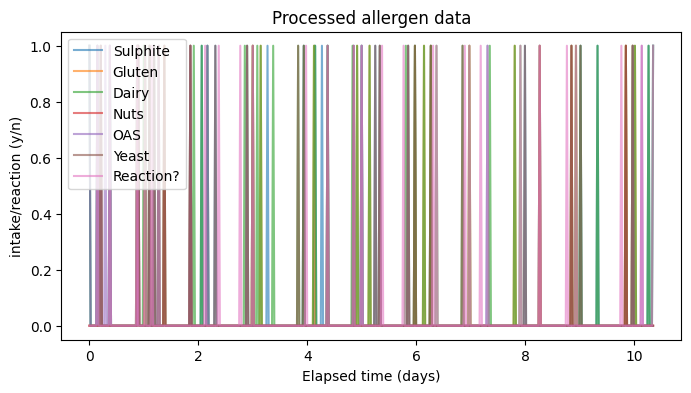

In [5]:
plt.figure(figsize=(8,4))
for i in range(7):
    plt.plot(analysisTimes/(3600*24),analysisData[:,i],alpha=0.6)
plt.legend(legendText, loc = 'upper left')
plt.title('Processed allergen data')
plt.xlabel('Elapsed time (days)')
plt.ylabel('intake/reaction (y/n)')
plt.show()

We also have additional information hidden in the recorded data. The data only records when a food was eaten, or a reaction detected. We therefore can also add all the 30 minute windows where no reaction took place when no food was eaten

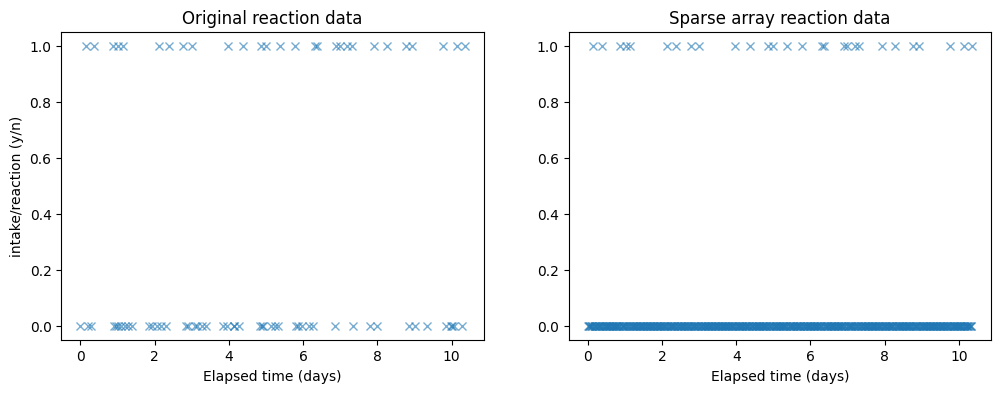

In [6]:
# Plot the original and sparse data arrays
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.xlabel('Elapsed time (days)')
plt.ylabel('intake/reaction (y/n)')
plt.plot(times/(3600*24),data[:,11],'x',alpha=0.6)
plt.title('Original reaction data')
plt.subplot(1,2,2)
plt.plot(analysisTimes/(3600*24),analysisData[:,6],'x',alpha=0.6)
plt.title('Sparse array reaction data')
plt.xlabel('Elapsed time (days)')
plt.show()

## 🔄 Cross-Correlation Analysis
- Used to measure the alignment between food ingestion and reported symptoms.
- Lag applied: from several hours before to after ingestion.
- High correlation peaks indicate a likely causal relationship.
- Initially, **dairy** showed the strongest correlation, followed by **sulphites**.
- After **normalisation** to account for frequency of consumption, **dairy and sulphites were equally implicated**.

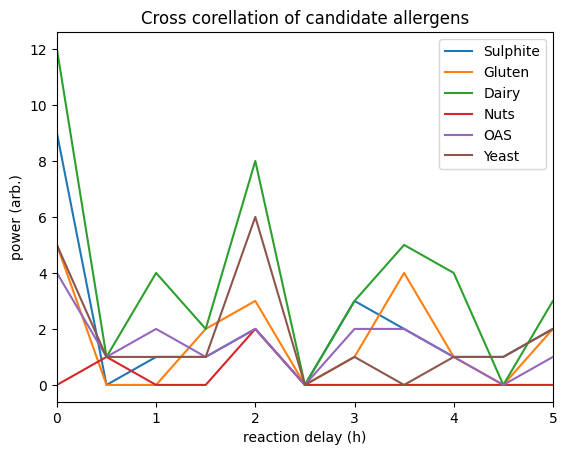

In [7]:
plt.figure()
for i in range(6):
    temp = np.correlate(analysisData[:,i],analysisData[:,-1],'full')
    plt.plot(lagXvalues,temp )
plt.legend(legendText, loc = 'upper right')
plt.title('Cross corellation of candidate allergens')
plt.xlabel('reaction delay (h)')
plt.ylabel('power (arb.)')
plt.xlim([-0,5])
plt.show()

It's important to note here that the cross correlation (the power of the overlapping ) is related to the number of times that item was taken, and the number of detection events. If the individual was constantly reacting to an unknown allergen, then this would falsely implicate the allergen that was eaten the most often.
Therefore, we take the [normalised cross-correlation](https://www.sciencedirect.com/topics/computer-science/normalized-cross-correlation) to account for the number of events.

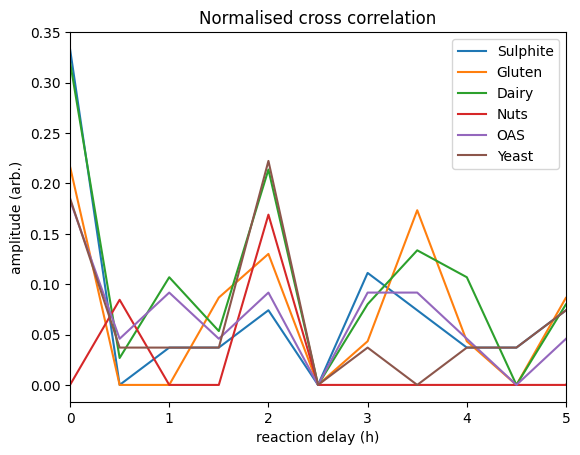

In [8]:
maxValues = np.zeros(6)
numberEvents = np.sqrt(np.sum(analysisData,axis=0))

plt.figure()
for i in range(6):
    temp = np.correlate(analysisData[:,i],analysisData[:,-1],'full')
    ncc = temp/(numberEvents[6]* numberEvents[i])
    maxValues[i] = max(ncc)
    plt.plot(lagXvalues,ncc)
plt.legend(legendText, loc = 'upper right')
plt.xlabel('reaction delay (h)')
plt.ylabel('amplitude (arb.)')
plt.title('Normalised cross correlation')
plt.xlim([0,5])
plt.show()

## 📈 Results Summary
- **Dairy** and **sulphites** had the highest normalised cross-correlation with symptoms.
- **OAS**, **gluten**, and **nuts** showed low correlation.
- Correlation peaks occurred within **30 minutes** after ingestion, and a second peak at two hours, although this could be caused by subsequent eating events.
- Results matched what a professional diagnosis later confirmed: **lactose and sulphite sensitivity**.

In [9]:
print('Total entries:')
for i in range(7):
        print(legendText[i] + " = " + str(np.count_nonzero(data[:,5+i])) )

Total entries:
Sulphite = 26
Gluten = 19
Dairy = 50
Nuts = 5
OAS = 17
Yeast = 26
Reaction? = 28


In [10]:
print('Maximum normalised cross correlation:')
for i in range(6):
    print( legendText[i] + " = " + str(round(maxValues[i],3)) )

Maximum normalised cross correlation:
Sulphite = 0.334
Gluten = 0.217
Dairy = 0.321
Nuts = 0.169
OAS = 0.183
Yeast = 0.222


## 🚀 Next Steps and Reflections
**If extended:**
- Develop a phone app to log symptoms and intake more easily.
- Collect data over a longer time period to explore dose-response relationships.
- Use **Monte Carlo simulations** or bootstrapping to estimate confidence intervals on correlations.
- Train a classifier or regression model to estimate symptom severity.
- Test null hypotheses: how likely are observed correlations under random intake?

**Reflection:**
- This project used personal experience and domain knowledge to prototype a unique use of time-series signal analysis in healthcare.
- It demonstrates exploratory research, cross-domain thinking, and initiative in problem-solving.

_This notebook was adapted from a technical presentation and the original Python code written during the 2020 lockdown._